In [ ]:
pip install imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier


In [150]:
df = pd.read_csv("/content/ai_resume_screening.csv")

le = LabelEncoder()
scaler = StandardScaler()

for col in df:
  if df[col].dtype == "object":
    df[col] = le.fit_transform(df[col])
  else:
    df[col] = scaler.fit_transform(df[col].values.reshape(-1, 1))



for col in df:
  if df[col].isnull().sum() > 0 and df[col].dtype != "object":
    df.fillna(df[col].mean(), inplace=True)


y = df['shortlisted']
x = df.drop(['shortlisted'], axis=1)


In [151]:
y.value_counts()

,count
shortlisted,
1,20966
0,9034


In [154]:
smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x, y)

print("Original y_train value counts:")
print(y.value_counts())
print("\nResampled y_train value counts (after SMOTE):")
print(y_resampled.value_counts())

Original y_train value counts:
shortlisted
1    20966
0     9034
Name: count, dtype: int64

Resampled y_train value counts (after SMOTE):
shortlisted
0    20966
1    20966
Name: count, dtype: int64


In [163]:
x_train, x_test, y_train, y_test = train_test_split(x_resampled, y_resampled, test_size=0.2, random_state=42)

In [164]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score)

xgb_model = XGBClassifier(
   n_estimators=300,
    learning_rate=0.1,
    max_depth=5,

    random_state=42,
    n_jobs=-1,

    colsample_bytree=0.7,
    subsample=0.8,

    objective='binary:logistic'
    # tree_method='auto'
   )

xgb_model.fit(x_train, y_train)
y_pred = xgb_model.predict(x_test)

accuracy_scores = accuracy_score(y_test, y_pred)
precision_scores = precision_score(y_test, y_pred)
recall_scores = recall_score(y_test, y_pred)
f1_scores = f1_score(y_test, y_pred) # caluculate metrics considering class imbalance

print(f"""
Accuracy Score : {accuracy_scores}
Precision Score : {precision_scores}
Recall Score : {recall_scores}
F1 Score : {f1_scores} """)

# r2_score = r2_score(y_test, y_pred)
# mae = mean_absolute_error(y_test, y_pred)
# mse = mean_squared_error(y_test, y_pred)

# print(f"R2 Score: {r2_score}")
# print(f"Mean Absolute Error: {mae}")
# print(f"Mean Squared Error: {mse}")


Accuracy Score : 0.9240491236437344
Precision Score : 0.9305962854349951
Recall Score : 0.9151646238884883
F1 Score : 0.9228159457167091 


In [166]:
y_train.value_counts()

,count
shortlisted,
1,16805
0,16740


In [167]:
y_test.value_counts()

,count
shortlisted,
0,4226
1,4161


              precision    recall  f1-score   support

           0       0.92      0.93      0.93      4226
           1       0.93      0.92      0.92      4161

    accuracy                           0.92      8387
   macro avg       0.92      0.92      0.92      8387
weighted avg       0.92      0.92      0.92      8387



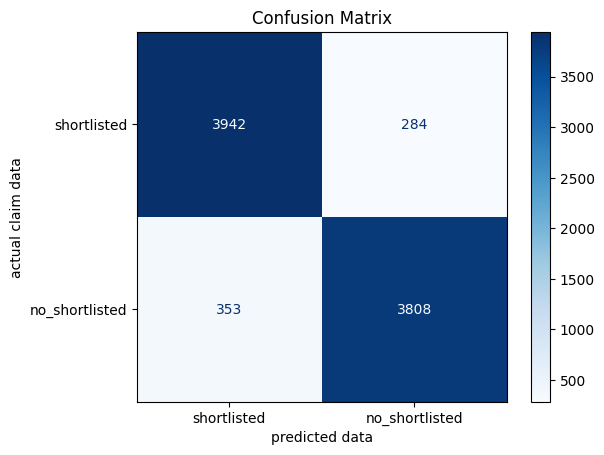

In [168]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['shortlisted', 'no_shortlisted']) # Assuming binary classification for 'liked'
disp.plot(cmap=plt.cm.Blues)

plt.xlabel('predicted data')
plt.ylabel('actual claim data')
plt.title('Confusion Matrix')
plt.show()

In [169]:
import joblib
if joblib.dump(xgb_model, 'resume_shortlisted.pkl'):
  print("model saved")

model saved
